# 线性回归的从零开始实现

In [118]:

%matplotlib inline
import random

import torch
from d2l import torch as d2l

## 生成数据集

构造一个很小的人造数据集，用于演示线性回归的基本原理。

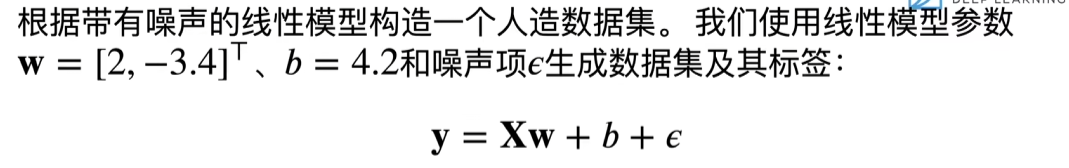

In [119]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))


true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [120]:
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([-0.0174,  0.4247]) 
label: tensor([2.7137])


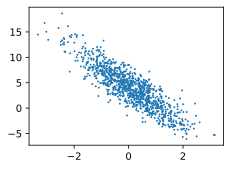

In [121]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

## 读取数据集

在读取数据集时，我们往往需要将数据集进行打乱处理，每次确保只抽取数据集之中的一小段样本，并确保它们来更新模型参数。

所以需要实现一个函数，这个函数主要实现的函数功能：

- 打乱数据集
- 从数据集之中读取一小部分样本

In [122]:
def data_iter(batch_size, features, labels):
    """
    从数据集 features 和 labels 中随机抽取 batch_size 个样本
    :param batch_size:数据子集的大小
    :param features:特征矩阵
    :param labels:标签向量
    """
    # 得到数据集的长度
    num_examples = len(features)
    # 生成随机数据，模拟数据集的随机打乱
    indices = list(range(num_examples))
    random.shuffle(indices)
    for index in range(0, num_examples, batch_size):
        batch_cls = torch.tensor(indices[index:min(index + batch_size, num_examples)])
        yield features[batch_cls], labels[batch_cls]

In [123]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.5884,  1.8396],
        [ 0.1253,  0.5361],
        [-0.4433,  1.5552],
        [-0.6117, -0.5899],
        [-0.4081,  1.9513],
        [-1.6230, -0.7938],
        [ 0.8120,  1.0500],
        [ 1.6435, -0.1765],
        [-0.0931, -0.6781],
        [ 0.0190,  1.2453]]) 
 tensor([[-8.7598e-01],
        [ 2.6239e+00],
        [-1.9667e+00],
        [ 4.9732e+00],
        [-3.2496e+00],
        [ 3.6509e+00],
        [ 2.2610e+00],
        [ 8.0873e+00],
        [ 6.3116e+00],
        [-3.9246e-03]])


初始化随机模型参数

在我们开始用小批量随机梯度下降优化我们的模型参数之前， 我们需要先有一些参数。 在下面的代码中，我们通过从均值为0、标准差为0.01的正态分布中采样随机数来初始化权重， 并将偏置初始化为0。

In [124]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
w, b

(tensor([[-0.0139],
         [ 0.0170]], requires_grad=True),
 tensor([0.], requires_grad=True))

定义模型

接下来我们将定义模型，将模型的输入和参数同模型的输出关联起来，计算输入特征`X`和模型权重`w`的矩阵-向量乘法后，加上偏置`b`。

In [125]:
# 定义线性回归方程
def linreg(X, W, b):
    """
    定义线性模型
    torch.matmul(a,b)的主要作用是：“实现a和b矩阵的乘法运算”
    """
    return torch.matmul(X, W) + b

In [126]:
# 定义损失函数
def squared_loss(y_hat, y):
    """
        均方损失
    """
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [127]:
# 定义优化算法：实现小批量随机梯度下降算法
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

在每一步中，使用从数据集中随机抽取的一个小批量，然后根据参数计算损失的梯度。 接下来，朝着减少损失的方向更新我们的参数。 下面的函数实现小批量随机梯度下降更新。 该函数接受模型参数集合、学习速率和批量大小作为输入。每 一步更新的大小由学习速率lr决定。 因为我们计算的损失是一个批量样本的总和，所以我们用批量大小（batch_size） 来规范化步长，这样步长大小就不会取决于我们对批量大小的选择。

训练

<font color="red">
现在我们已经准备好了模型训练所有需要的要素，可以实现主要的训练过程部分了。 理解这段代码至关重要，因为从事深度学习后， 相同的训练过程几乎一遍又一遍地出现。
</font>

</br>

<font color="red">
在每次迭代中，我们读取一小批量训练样本，并通过我们的模型来获得一组预测。 计算完损失后，我们开始反向传播，存储每个参数的梯度。 最后，我们调用优化算法sgd来更新模型参数。
</font>


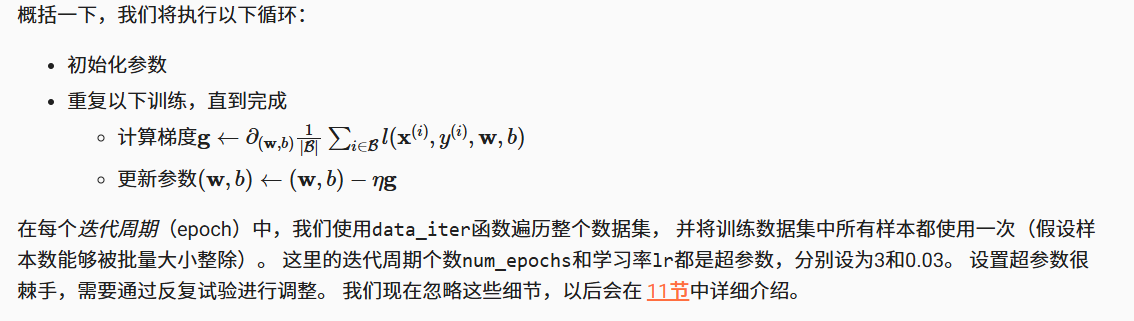

In [128]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.046730
epoch 2, loss 0.000193
epoch 3, loss 0.000051


In [129]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 5.8293e-05, -4.6968e-04], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0012], grad_fn=<RsubBackward1>)


## 线性回归的简洁实现

In [130]:
# 模拟数据集
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [131]:
# 读取数据集
def load_array(data_array, batch_size, is_train=True):
    """
    我们可以调用框架中现有的API来读取数据。 我们将features和labels作为API的参数传递，并通过数据迭代器指定batch_size。 此外，布尔值is_train表示是否希望数据迭代器对象在每个迭代周期内打乱数据。
    """
    data_set = data.TensorDataset(*data_array)
    return data.DataLoader(data_set, batch_size, shuffle=is_train)


batch_size = 10
data_iter = load_array((features, labels), batch_size)

next(iter(data_iter))

[tensor([[ 0.4288,  0.6466],
         [ 0.1211,  1.3789],
         [ 0.7512,  0.7740],
         [ 0.4907, -0.2413],
         [-0.1110,  0.5617],
         [-1.5045, -1.1434],
         [-0.9639,  0.9751],
         [ 0.1760, -0.1895],
         [ 0.0845,  0.5472],
         [-0.5155,  0.5110]]),
 tensor([[ 2.8554],
         [-0.2438],
         [ 3.0604],
         [ 5.9928],
         [ 2.0759],
         [ 5.0959],
         [-1.0509],
         [ 5.1984],
         [ 2.5136],
         [ 1.4304]])]

In [132]:
# 构建模型
from torch import nn

# 构建单层网络架构，单层网络架构一般被称为“全连接层”
# nn.Sequential():将多个神经网络层 / 模块按固定顺序线性串联，自动完成前向传播，无需手动编写 forward 函数逻辑。

net = nn.Sequential(nn.Linear(2, 1))

In [133]:
# 初始化模型参数
# 在使用net之前，我们需要初始化模型参数。 如在线性回归模型中的权重和偏置。 深度学习框架通常有预定义的方法来初始化参数。 在这里，我们指定每个权重参数应该从均值为0、标准差为0.01的正态分布中随机采样， 偏置参数将初始化为零。

# 设置均值和标准差，将均值设置为0，标准差设置为0.01
net[0].weight.data.normal_(0, 0.01)
# 将偏置值设置为0
net[0].bias.data.fill_(0)

tensor([0.])

In [134]:
# 定义损失函数
loss = nn.MSELoss()

In [135]:
# 定义优化算法
# 小批量随机梯度下降算法是一种优化神经网络的标准工具， PyTorch在optim模块中实现了该算法的许多变种。 当我们实例化一个SGD实例时，我们要指定优化的参数 （可通过net.parameters()从我们的模型中获得）以及优化算法所需的超参数字典。 小批量随机梯度下降只需要设置lr值，这里设置为0.03。
trainer = torch.optim.SGD(net.parameters(), lr=0.03)
trainer

SGD (
Parameter Group 0
    dampening: 0
    lr: 0.03
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [136]:
# 训练
# 回顾一下：在每个迭代周期里，我们将完整遍历一次数据集（train_data）， 不停地从中获取一个小批量的输入和相应的标签。 对于每一个小批量，我们会进行以下步骤:
# - 通过调用net(X)生成预测并计算损失l（前向传播）。
# - 通过进行反向传播来计算梯度。
# - 通过调用优化器来更新模型参数。


# 1. 定义训练总轮数
num_epochs = 3
# 2. 外层循环：遍历每一个训练轮次（epoch）
for epoch in range(num_epochs):
    # 3. 内层循环：遍历【一个批次】的训练数据（小批量梯度下降）
    for X, y in data_iter:
        # 4. 前向传播：模型预测 → 计算损失值（预测值和真实值的误差）
        l = loss(net(X), y)
        # 5. 清空梯度：PyTorch梯度会累加，必须清空上一步的梯度
        trainer.zero_grad()
        # 6. 反向传播：自动计算所有参数的梯度（求导）
        l.backward()
        # 7. 更新参数：优化器根据梯度，调整模型的权重/偏置
        trainer.step()

    # 8. 一轮训练结束后：用全部数据计算最终损失，监控训练效果
    l = loss(net(features), labels)
    # 9. 打印当前轮次 + 损失值（损失越小，模型拟合得越好）
    print(f'epoch {epoch + 1}, loss {float(l.mean()):f}')

epoch 1, loss 0.000229
epoch 2, loss 0.000103
epoch 3, loss 0.000104


In [137]:
w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

w的估计误差： tensor([ 0.0005, -0.0005])
b的估计误差： tensor([0.0003])
